In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
from google.colab import files
uploaded = files.upload()

Saving AB_NYC_2019.csv.zip to AB_NYC_2019.csv.zip


In [5]:
import zipfile
import pandas as pd

# Extract ZIP file
with zipfile.ZipFile('AB_NYC_2019.csv.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

# Load CSV from extracted folder
df = pd.read_csv('data/AB_NYC_2019.csv')

print(df.head())

     id                                              name  host_id  \
0  2539                Clean & quiet apt home by the park     2787   
1  2595                             Skylit Midtown Castle     2845   
2  3647               THE VILLAGE OF HARLEM....NEW YORK !     4632   
3  3831                   Cozy Entire Floor of Brownstone     4869   
4  5022  Entire Apt: Spacious Studio/Loft by central park     7192   

     host_name neighbourhood_group neighbourhood  latitude  longitude  \
0         John            Brooklyn    Kensington  40.64749  -73.97237   
1     Jennifer           Manhattan       Midtown  40.75362  -73.98377   
2    Elisabeth           Manhattan        Harlem  40.80902  -73.94190   
3  LisaRoxanne            Brooklyn  Clinton Hill  40.68514  -73.95976   
4        Laura           Manhattan   East Harlem  40.79851  -73.94399   

         room_type  price  minimum_nights  number_of_reviews last_review  \
0     Private room    149               1                  9  20

Basic information

In [6]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

Shape of Dataset:
(48895, 16)

Column Names:
Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude           

Check Missing Values

In [7]:
print("Missing Values:\n")
print(df.isnull().sum())

# Percentage of missing values
missing_percentage = (df.isnull().sum()/len(df))*100

print("\nMissing Value Percentage:")
print(missing_percentage.sort_values(ascending=False))

Missing Values:

id                                    0
name                                 16
host_id                               0
host_name                            21
neighbourhood_group                   0
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                                 0
minimum_nights                        0
number_of_reviews                     0
last_review                       10052
reviews_per_month                 10052
calculated_host_listings_count        0
availability_365                      0
dtype: int64

Missing Value Percentage:
last_review                       20.558339
reviews_per_month                 20.558339
host_name                          0.042949
name                               0.032723
neighbourhood_group                0.000000
neighbourhood                      0.000000
id                                 0.00

Visualize Missing Values

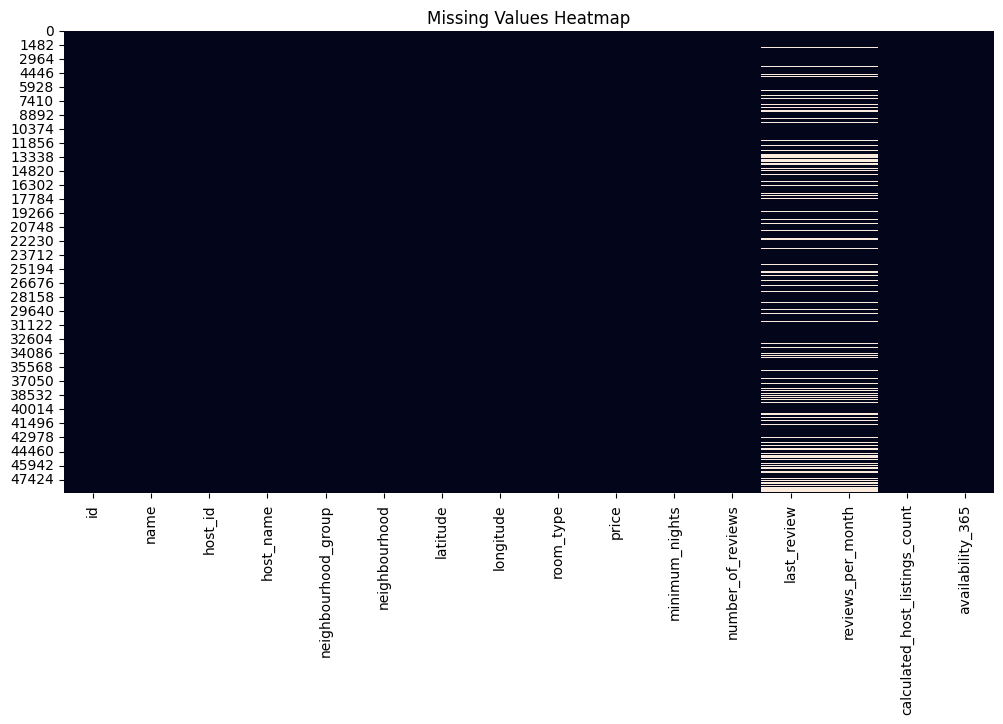

In [8]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

Handle Missing Values

In [9]:
# Fill host_name

df['host_name'].fillna("Unknown", inplace=True)

# Fill last_review

df['last_review'].fillna("Not Reviewed", inplace=True)

# Fill reviews_per_month

df['reviews_per_month'].fillna(df['reviews_per_month'].median(), inplace=True)

/tmp/ipykernel_4191/281741089.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['host_name'].fillna("Unknown", inplace=True)
/tmp/ipykernel_4191/281741089.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [10]:
print(df[['host_name','last_review','reviews_per_month']].isnull().sum())

host_name            0
last_review          0
reviews_per_month    0
dtype: int64


Check Duplicate Records

In [11]:
duplicates = df.duplicated().sum()

print("Duplicate Records:", duplicates)

Duplicate Records: 0


Standardize Column Names

In [12]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.strip()

print(df.columns)

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365'],
      dtype='object')


Standardize Text Columns

In [13]:
df['room_type'] = df['room_type'].str.strip().str.title()

df['neighbourhood_group'] = df['neighbourhood_group'].str.strip().str.title()

df['neighbourhood'] = df['neighbourhood'].str.strip().str.title()

Check Invalid Values

In [14]:
print(df[df['price'] < 0])

Empty DataFrame
Columns: [id, name, host_id, host_name, neighbourhood_group, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365]
Index: []


In [15]:
print(df[df['minimum_nights'] < 0])

Empty DataFrame
Columns: [id, name, host_id, host_name, neighbourhood_group, neighbourhood, latitude, longitude, room_type, price, minimum_nights, number_of_reviews, last_review, reviews_per_month, calculated_host_listings_count, availability_365]
Index: []


Price Distribution Before Outlier Removal

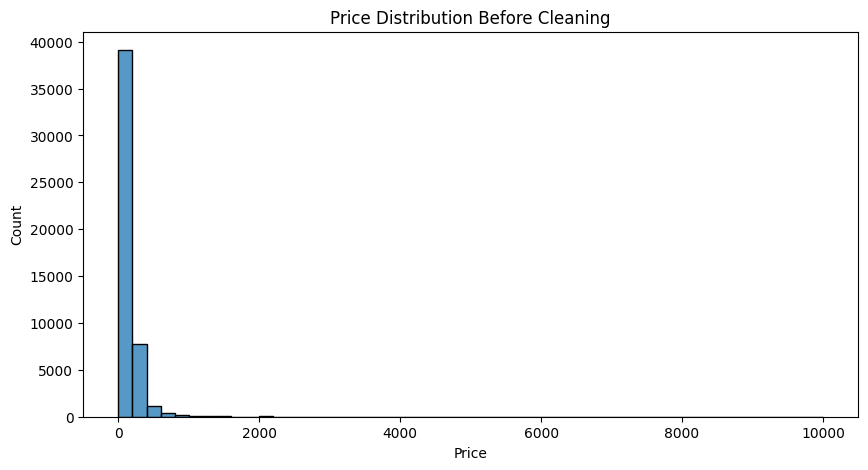

In [16]:
plt.figure(figsize=(10,5))

sns.histplot(df['price'], bins=50)

plt.title("Price Distribution Before Cleaning")
plt.xlabel("Price")
plt.show()

Detect Outliers Using IQR

In [17]:
Q1 = df['price'].quantile(0.25)

Q3 = df['price'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -90.0
Upper Bound: 334.0


Count Outliers

In [18]:
outliers = df[(df['price'] < lower_bound) |
              (df['price'] > upper_bound)]

print("Total Outliers:", len(outliers))

Total Outliers: 2972


Boxplot Before Cleaning

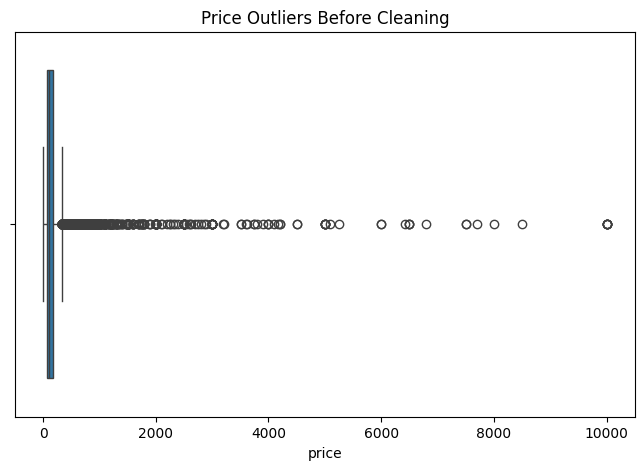

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df['price'])

plt.title("Price Outliers Before Cleaning")
plt.show()

Remove Outliers

In [20]:
df_clean = df[(df['price'] >= lower_bound) &
              (df['price'] <= upper_bound)]

print("Original Shape:", df.shape)
print("Cleaned Shape:", df_clean.shape)

Original Shape: (48895, 16)
Cleaned Shape: (45923, 16)


Boxplot After Cleaning

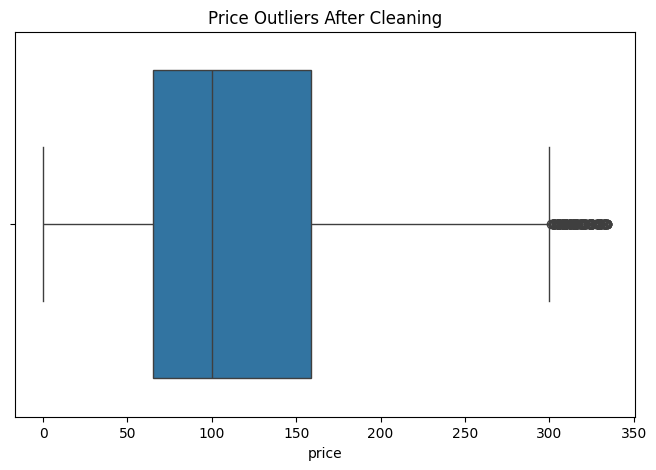

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean['price'])

plt.title("Price Outliers After Cleaning")
plt.show()

Room Type Analysis

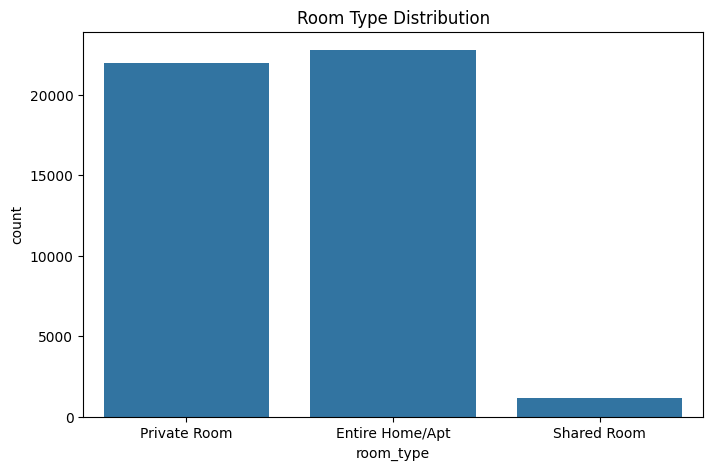

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean,
              x='room_type')

plt.title("Room Type Distribution")

plt.show()

Neighbourhood Group Analysis

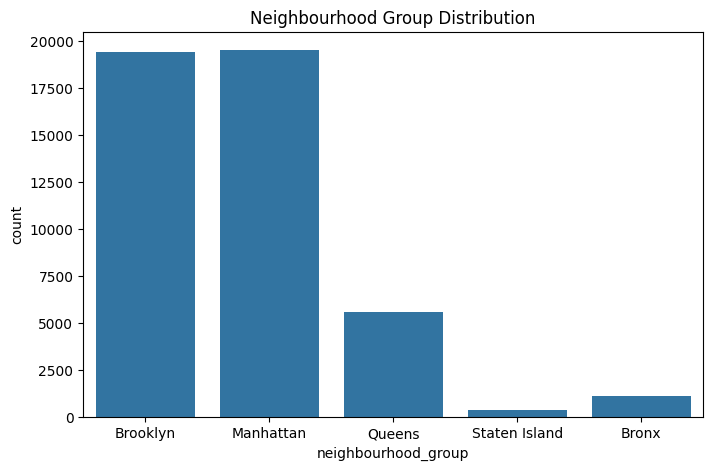

In [23]:
plt.figure(figsize=(8,5))

sns.countplot(data=df_clean,
              x='neighbourhood_group')

plt.title("Neighbourhood Group Distribution")

plt.show()

Average Price by Room Type

room_type
Entire Home/Apt    162.527096
Private Room        79.018503
Shared Room         59.293497
Name: price, dtype: float64


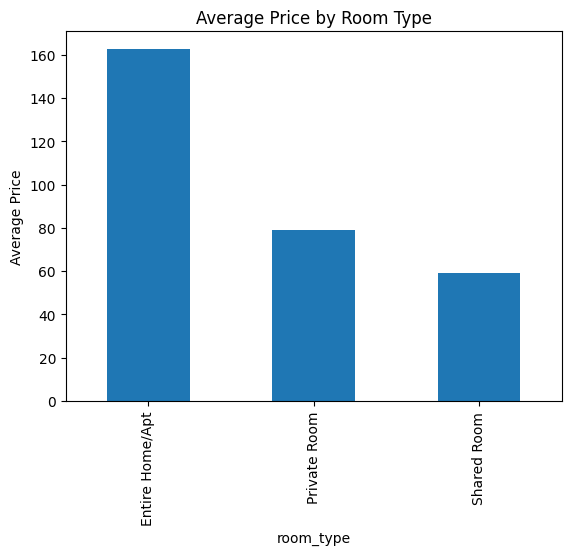

In [24]:
avg_price = df_clean.groupby('room_type')['price'].mean()

print(avg_price)

avg_price.plot(kind='bar')

plt.title("Average Price by Room Type")

plt.ylabel("Average Price")

plt.show()

Correlation Analysis

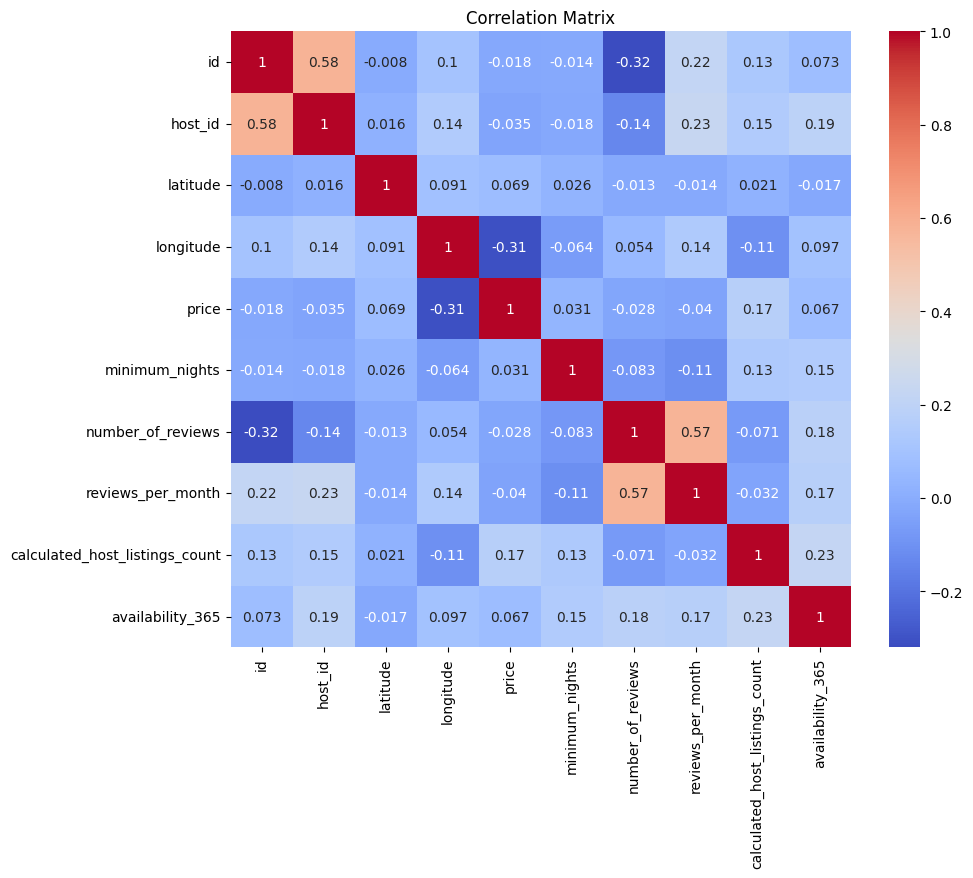

In [25]:
numeric_columns = df_clean.select_dtypes(include=np.number)

correlation = numeric_columns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Matrix")

plt.show()

Save Cleaned Dataset

In [26]:
df_clean.to_csv("NYC_Airbnb_Cleaned.csv",
                index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


**Conclusion**
- Missing values were found in host_name, last_review, and reviews_per_month.
- Missing values were handled using imputation techniques.
- Duplicate records were checked and removed.
- Text columns were standardized.
- Extreme price outliers were detected using the IQR method and removed.
- The cleaned dataset became more reliable for analysis and machine learning.